# GEARS — Notebook 1: GMM & VAE Descriptive Analysis

**Objective:** Thorough descriptive analysis of the pre-fitted generative models in the GEARS registry —
both the **GMM** family (`'french'` bundle) and the newer **VAE** family (`'french_vae_sample'` bundle).

No raw data is required — both models are fitted/shipped with the package and are loaded straight from
`NativeSessionModelRegistry`. Throughout this notebook, every GMM feature is paired with the equivalent VAE call to
show that `EVSessionModel(model_type="vae")` exposes the **same public API** (`.sample()`, `.score()`,
`.plot_marginals()`, `.plot_components()`, `.bic_summary()`, `.get_sklearn_component()`, ...) — the two are
interchangeable from the caller's point of view, even though internally one is a per-context Gaussian
Mixture and the other is a conditional VAE decoder.

> **Note on naming:** the VAE registry entry actually ships under the key `"french_vae_sample"` (top-5
> departments, `is_sample_=True`) rather than `"french_vae"` — this notebook uses the real key.

**Sections**
1. Load GMM (and VAE) from the registry
2. Access the underlying model objects (`sklearn` GMM vs. `VAEContextSlice`)
3. Component weights and means (GMM) / empirical equivalents (VAE)
4. Descriptive statistics per stratum — GMM vs VAE
5. Session distributions by location type — `plot_marginals()`, GMM vs VAE
6. Seasonal patterns (arrival hour by season) — GMM vs VAE
7. Day-of-week patterns — GMM vs VAE
8. Département coverage map — GMM (full) vs VAE (sample)
9. BIC component count summary — GMM vs VAE

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os; os.makedirs("outputs", exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.mixture import GaussianMixture

import gears
from gears import NativeSessionModelRegistry, get_session_model, load_sessions
from gears.data.schemas import _season
from gears.models.vae import VAEContextSlice  # noqa: F401 (for isinstance / type display below)

## 1. Load GMM from the registry

Use `NativeSessionModelRegistry` to list and load the unified French bundle.  
The single `'french'` bundle covers all location types, stratified by  
`location_type × département × day_of_week × season`.

In [2]:
registry = NativeSessionModelRegistry()
print(registry)
print()
print(registry.list().to_string(index=False))

NativeSessionModelRegistry(2/2 GMMs available, dir=/home/claude/work/GEARS/gears/data/session_models)

 session_model_id model_type                                                                                                                                                               description  available  is_sample                                      stratify_by
           french        gmm                 French national EV dataset — single GMM stratified by location_type × département × season × day_of_week (8 008 contexts, full dataset, is_sample=False).       True      False [location_type, department, day_of_week, season]
french_vae_sample        vae French EV sample dataset — shared conditional VAE stratified by location_type × département × season × day_of_week (top-5 departments, is_sample=True, model_type='vae').       True       True [location_type, department, day_of_week, season]


In [3]:
# Single unified bundle — all location types in one EVSessionModel object
gmm = registry.load("french")

n_ctx  = len(gmm.models_)
flag   = "⚠  sample data" if gmm.is_sample_ else "✓  full data"
locs   = sorted(set(c[0] for c in gmm.list_contexts()))
depts  = sorted(set(c[1] for c in gmm.list_contexts()))

print(f"Loaded GMM: {n_ctx} contexts | stratify_by={gmm.stratify_by} | {flag}")
print(f"Location types : {locs}")
print(f"Departments    : {depts}")
if gmm.metadata_:
    print(f"Metadata       : {gmm.metadata_}")

Loaded GMM: 8008 contexts | stratify_by=['location_type', 'department', 'day_of_week', 'season'] | ✓  full data
Location types : ['heavy', 'home', 'public', 'work']
Departments    : ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '21', '22', '23', '24', '25', '26', '27', '28', '29', '2a', '2b', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '6', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '7', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '8', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '9', '90', '91', '92', '93', '94', '95', '971', '972', '974', '978']
Metadata       : {'gmm_id': 'french', 'n_training_sessions': 8357487, 'stratify_by': ['location_type', 'department', 'day_of_week', 'season'], 'year': 2025}


In [4]:
# First 12 context keys — each is (location_type, department, day_of_week, season)
print("French GMM — fitted context keys (first 12):")
for ctx in list(gmm.list_contexts())[:12]:
    print(f"  {ctx}")
print(f"  ... ({len(gmm.list_contexts())} total)")

French GMM — fitted context keys (first 12):
  ('heavy', '1', 0, 'autumn')
  ('heavy', '1', 0, 'spring')
  ('heavy', '1', 0, 'summer')
  ('heavy', '1', 0, 'winter')
  ('heavy', '1', 1, 'autumn')
  ('heavy', '1', 1, 'spring')
  ('heavy', '1', 1, 'summer')
  ('heavy', '1', 1, 'winter')
  ('heavy', '1', 2, 'autumn')
  ('heavy', '1', 2, 'spring')
  ('heavy', '1', 2, 'summer')
  ('heavy', '1', 2, 'winter')
  ... (8008 total)


### 1.1 Load the VAE bundle from the registry — same API

`NativeSessionModelRegistry.load()` is model-agnostic: the exact same call pattern retrieves the VAE bundle.
`"french_vae_sample"` is a **sample** bundle (`is_sample_=True`), fitted on the top-5 busiest départements
only — a smaller companion to the full `"french"` GMM bundle, not a drop-in replacement for it.

In [5]:
# Same retrieval call as cell above, different key — model_type is handled internally
vae = registry.load("french_vae_sample")

n_ctx_vae  = len(vae.models_)
flag_vae   = "⚠  sample data" if vae.is_sample_ else "✓  full data"
locs_vae   = sorted(set(c[0] for c in vae.list_contexts()))
vae_has_dept = "department" in vae.stratify_by
depts_vae  = (
    sorted(set(dict(zip(vae.stratify_by, c))["department"] for c in vae.list_contexts()))
    if vae_has_dept else []
)

print(f"Loaded VAE: {n_ctx_vae} contexts | stratify_by={vae.stratify_by} | {flag_vae} | model_type={vae.model_type}")
print(f"Location types : {locs_vae}")
print(f"Departments    : {depts_vae if vae_has_dept else '(not a stratification dimension for this bundle — stratify_by=' + repr(vae.stratify_by) + ')'}")

print("\n── GMM vs VAE bundle summary ─────────────────────────────────────────────")
print(pd.DataFrame([
    {"bundle": "french (GMM)",      "n_contexts": n_ctx, "n_departments": len(depts),     "is_sample": gmm.is_sample_},
    {"bundle": "french_vae_sample", "n_contexts": n_ctx_vae, "n_departments": len(depts_vae), "is_sample": vae.is_sample_},
]).to_string(index=False))

Loaded VAE: 516 contexts | stratify_by=['location_type', 'department', 'day_of_week', 'season'] | ✓  full data | model_type=vae
Location types : ['heavy', 'home', 'public', 'work']
Departments    : ['59', '69', '78', '92', '93']

── GMM vs VAE bundle summary ─────────────────────────────────────────────
           bundle  n_contexts  n_departments  is_sample
     french (GMM)        8008            100      False
french_vae_sample         516              5      False


In [6]:
# ── Département alignment: GMM ("french") vs VAE ("french_vae_sample") ──────
# The VAE "sample" bundle is meant to cover a curated handful of real French
# départements, stratified the same way as the GMM (see NativeSessionModelRegistry's
# catalogue docstring: stratify_by includes "department"). `import gears` fetches
# vae_french_sample.joblib from the models-v1 GitHub release the first time it's
# needed (see gears/_fetch_models.py) rather than shipping it in the repo — if that
# fetch can't complete (e.g. no network in this environment) and the file still
# isn't present, NativeSessionModelRegistry transparently falls back to a small
# synthetic demo
# (documented behaviour — see registry.py's _generate_fallback) that doesn't
# stratify by département at all. Both cases are handled explicitly below
# rather than assumed away; see REFACTOR_STATE.md for the full writeup of
# this gap.
is_synthetic_vae = bool(vae.metadata_.get("synthetic_fallback"))
if not vae_has_dept:
    GMM_DEMO_DEPT, VAE_DEMO_DEPT = sorted(depts)[0], None
    print(
        f"Note: the loaded VAE bundle does not stratify by département at all "
        f"(vae.stratify_by={vae.stratify_by!r}). "
        + ("It's running on its synthetic fallback (real curated bundle not "
           "present in this environment). " if is_synthetic_vae else "")
        + "Département-specific cells below use the GMM's own représentative "
        "département only; the VAE side is département-agnostic here."
    )
else:
    shared_depts = sorted(set(map(str, depts)) & set(map(str, depts_vae)))
    if shared_depts:
        GMM_DEMO_DEPT = VAE_DEMO_DEPT = shared_depts[0]
    else:
        GMM_DEMO_DEPT, VAE_DEMO_DEPT = sorted(depts)[0], depts_vae[0]
        print(
            "Note: no département is shared between the GMM ('french') and VAE "
            "('french_vae_sample') bundles in this environment (GMM sample: "
            f"{sorted(depts)[:3]}..., VAE sample: {sorted(depts_vae)}). "
            "Side-by-side cells below compare each bundle against its own "
            "representative département rather than a literally shared one."
        )
print(f"GMM demo département: {GMM_DEMO_DEPT!r} | VAE demo département: {VAE_DEMO_DEPT!r}")


GMM demo département: '59' | VAE demo département: '59'


## 2. Access the underlying sklearn GaussianMixture objects

Two access patterns are available:
- `gmm.get_sklearn_component(context=...)` on the EVSessionModel wrapper
- `gears.get_session_model(bundle_id)` for the registry retrieval API

Feature space: `[arrival_hour, log1p(duration_h), log1p(energy_kWh)]`

In [7]:
# Pattern 1 — direct context dict on the loaded GMM
ctx_key  = gmm.list_contexts()[0]
ctx_dict = dict(zip(gmm.stratify_by, ctx_key))
print(f"Context: {ctx_dict}")

sk_gmm: GaussianMixture = gmm.get_sklearn_component(context=ctx_dict)
print(f"\nsklearn type  : {type(sk_gmm).__name__}")
print(f"n_components  : {sk_gmm.n_components}")
print(f"covariance    : {sk_gmm.covariance_type}")
print(f"Weights       : {sk_gmm.weights_.round(3)}")

# Back-transform means to human-readable units
means_bt = sk_gmm.means_.copy()
means_bt[:, 1] = np.expm1(means_bt[:, 1])   # log1p(duration) → hours
means_bt[:, 2] = np.expm1(means_bt[:, 2])   # log1p(energy)   → kWh
print("\nComponent means (back-transformed):")
print(pd.DataFrame(means_bt, columns=["Arrival hour", "Duration (h)", "Energy (kWh)"]).round(2).to_string())

Context: {'location_type': 'heavy', 'department': '1', 'day_of_week': 0, 'season': 'autumn'}

sklearn type  : GaussianMixture
n_components  : 6
covariance    : full
Weights       : [0.029 0.412 0.324 0.029 0.088 0.118]

Component means (back-transformed):
   Arrival hour  Duration (h)  Energy (kWh)
0         11.00          0.68          2.30
1         15.24         15.52         34.06
2         12.64          1.80         33.71
3          5.13          2.76         53.69
4          7.82          1.24         14.63
5         11.73         16.95         45.97


In [8]:
# Pattern 2 — registry retrieval API: gears.get_session_model(bundle_id)
gmm_retrieved = get_session_model("french")
print("Retrieved via get_session_model('french'):")
print(repr(gmm_retrieved))

# Sample 20 sessions for Hauts-de-Seine / work / winter / Monday
ctx_paris = {"location_type": "work", "department": "92", "season": "winter", "day_of_week": 0}
sessions_sample = gmm_retrieved.sample(20, context=ctx_paris, seed=42)
print("\nSampled 20 sessions (Hauts-de-Seine, work, winter, Monday):")
print(sessions_sample[["arrival_hour", "duration", "energy"]].round(2).head(5))

Retrieved via get_session_model('french'):
EVSessionModel(n_contexts=8008, stratify_by=['location_type', 'department', 'day_of_week', 'season'], n_components='auto', max_samples=5000, fitted=True)

Sampled 20 sessions (Hauts-de-Seine, work, winter, Monday):
   arrival_hour  duration  energy
0          6.68     11.41   21.30
1          6.84      9.08    9.75
2          7.91      9.14   14.91
3          5.81      8.51   17.10
4          5.50     10.47   14.43


### 2.1 Same access pattern for the VAE

`vae.get_sklearn_component(context=...)` returns a `VAEContextSlice` instead of a `GaussianMixture`, but it
duck-types the same interface used elsewhere in the package (`.sample()`, `.score_samples()`,
`.weights_`, `.n_components`). Unlike the pre-Session-2 `get_gmm()` (hardcoded to the `"french"` bundle),
`gears.get_session_model("french_vae_sample")` works directly as the VAE shortcut — equivalent to the
registry call above (`registry.load("french_vae_sample")`).

In [9]:
# Pattern 1 — direct context dict, VAE this time
ctx_dict_vae = next(
    d for d in (dict(zip(vae.stratify_by, c)) for c in vae.list_contexts())
    if d.get("location_type") == "work" and d.get("department") == VAE_DEMO_DEPT
)
print(f"Context: {ctx_dict_vae}")

sk_vae: VAEContextSlice = vae.get_sklearn_component(context=ctx_dict_vae)
print(f"\nobject type   : {type(sk_vae).__name__}")
print(f"n_components  : {sk_vae.n_components}   (always 1 — the VAE is a single conditional decoder per context,")
print(f"weights_      : {sk_vae.weights_}        not a discrete mixture, so there is nothing to enumerate)")

# Same .sample() call signature as the GMM pattern above
sessions_sample_vae = vae.sample(20, context=ctx_dict_vae, seed=42)
print("\nSampled 20 sessions (Hauts-de-Seine, work, winter→ nearest available season, Monday):")
print(sessions_sample_vae[["arrival_hour", "duration", "energy"]].round(2).head(5))

Context: {'location_type': 'work', 'department': '59', 'day_of_week': 0, 'season': 'autumn'}

object type   : VAEContextSlice
n_components  : 1   (always 1 — the VAE is a single conditional decoder per context,
weights_      : [1.]        not a discrete mixture, so there is nothing to enumerate)

Sampled 20 sessions (Hauts-de-Seine, work, winter→ nearest available season, Monday):
   arrival_hour  duration  energy
0          5.95      3.06   13.71
1          5.71      4.67   44.42
2          4.38      8.23    9.84
3         14.52      3.79   26.37
4         14.30      0.64   13.11


## 3. Component weights and means

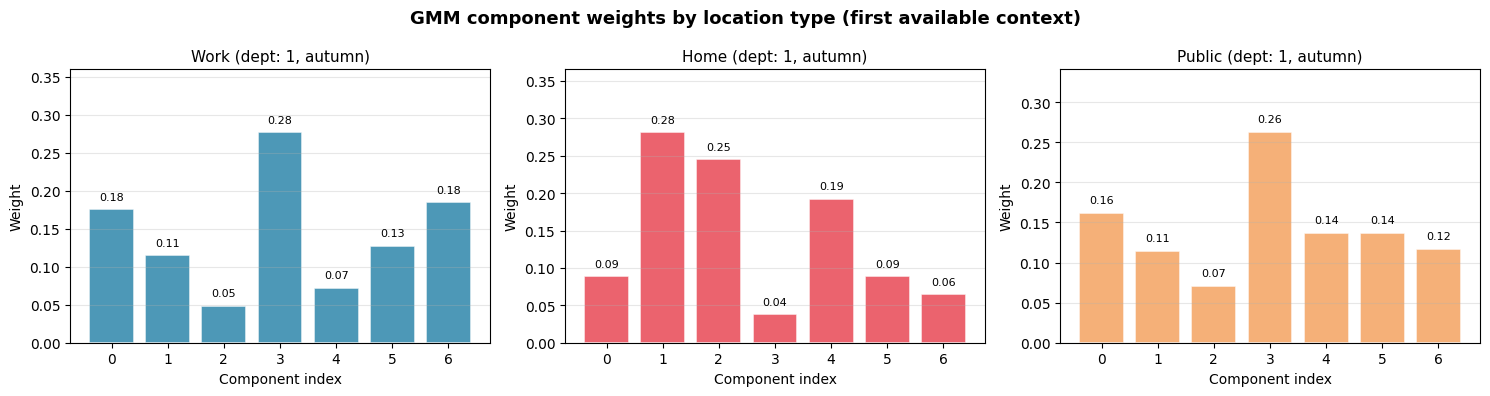

In [10]:
# ── Component weight bar chart — one subplot per location type ──────────────
COLORS = {"work": "#2E86AB", "home": "#E84855", "public": "#F4A261", "heavy": "#3BB273"}
loc_types = ["work", "home", "public"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, loc in zip(axes, loc_types):
    ctx_key  = next(c for c in gmm.list_contexts() if c[0] == loc)
    ctx_dict = dict(zip(gmm.stratify_by, ctx_key))
    sk       = gmm.get_sklearn_component(context=ctx_dict)
    k = sk.n_components
    bars = ax.bar(range(k), sk.weights_, color=COLORS[loc], alpha=0.85,
                  edgecolor="white", linewidth=1.2)
    for bar, w in zip(bars, sk.weights_):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{w:.2f}", ha="center", va="bottom", fontsize=8)
    ax.set_title(f"{loc.capitalize()} (dept: {ctx_key[1]}, {ctx_key[3]})", fontsize=11)
    ax.set_xlabel("Component index"); ax.set_ylabel("Weight")
    ax.set_xticks(range(k))
    ax.set_ylim(0, max(sk.weights_) * 1.3)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("GMM component weights by location type (first available context)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/01_component_weights.png", dpi=150, bbox_inches="tight")
plt.show()

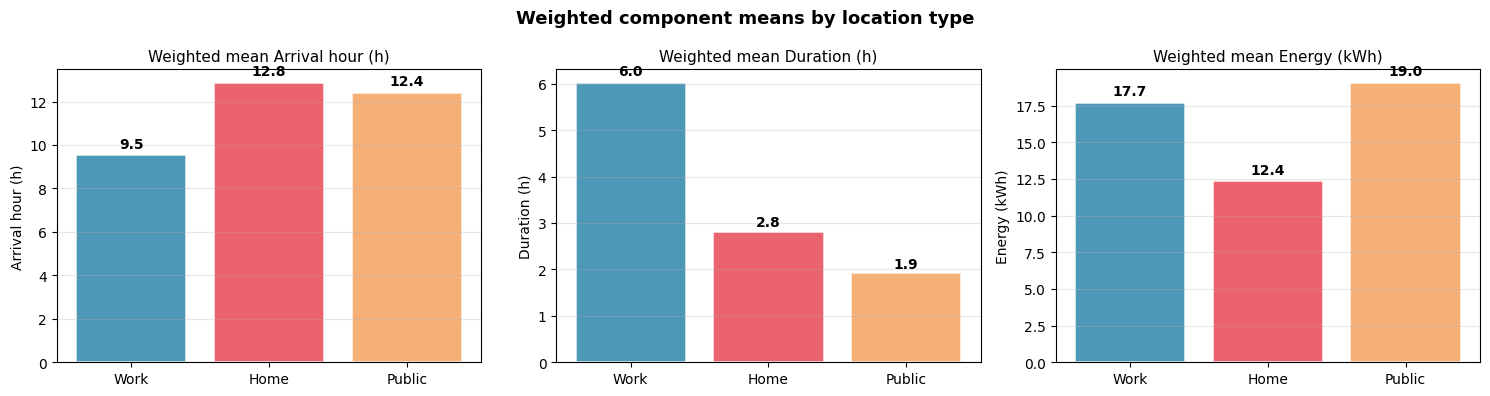

In [11]:
# ── Aggregate component means across all contexts (weighted by mixture weights) ─
def aggregate_means(gmm_obj, loc_filter=None):
    rows = []
    for ctx, sk in gmm_obj.models_.items():
        ctx_d = dict(zip(gmm_obj.stratify_by, ctx))
        if loc_filter and ctx_d.get("location_type") != loc_filter:
            continue
        for k in range(sk.n_components):
            rows.append({
                "location_type": ctx_d.get("location_type", "?"),
                "component": k,
                "weight": sk.weights_[k],
                "arrival_hour": sk.means_[k, 0],
                "duration_h": np.expm1(sk.means_[k, 1]),
                "energy_kwh": np.expm1(sk.means_[k, 2]),
            })
    return pd.DataFrame(rows)

all_means = aggregate_means(gmm)

# ── Weighted mean per metric per location type ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [("arrival_hour", "Arrival hour (h)"),
           ("duration_h",   "Duration (h)"),
           ("energy_kwh",   "Energy (kWh)")]

for ax, (metric, label) in zip(axes, metrics):
    vals, labels, colors = [], [], []
    for loc in ["work", "home", "public"]:
        sub = all_means[all_means["location_type"] == loc]
        if sub.empty:
            continue
        w_mean = np.average(sub[metric], weights=sub["weight"])
        vals.append(w_mean); labels.append(loc.capitalize())
        colors.append(COLORS[loc])
    bars = ax.bar(labels, vals, color=colors, alpha=0.85, edgecolor="white", linewidth=1.2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f"{v:.1f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_ylabel(label)
    ax.set_title(f"Weighted mean {label}", fontsize=11)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Weighted component means by location type", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/01_location_means.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.1 VAE has no interpretable components — the empirical equivalent

Since `VAEContextSlice.n_components == 1`, there are no per-component weights/means to read off directly
(a bar chart of "weights" would just be a single bar of height 1 — not informative). The API-equivalent
way to get the same *statistics* out of the VAE is to sample from it and compute empirical means — which
is exactly what `.sample()` is for. This cell reproduces the GMM's "weighted mean by location type" chart
above, but for the VAE, via empirical sampling, restricted to whichever départements the VAE bundle
actually covers in this environment (printed above) so the comparison stays apples-to-apples.


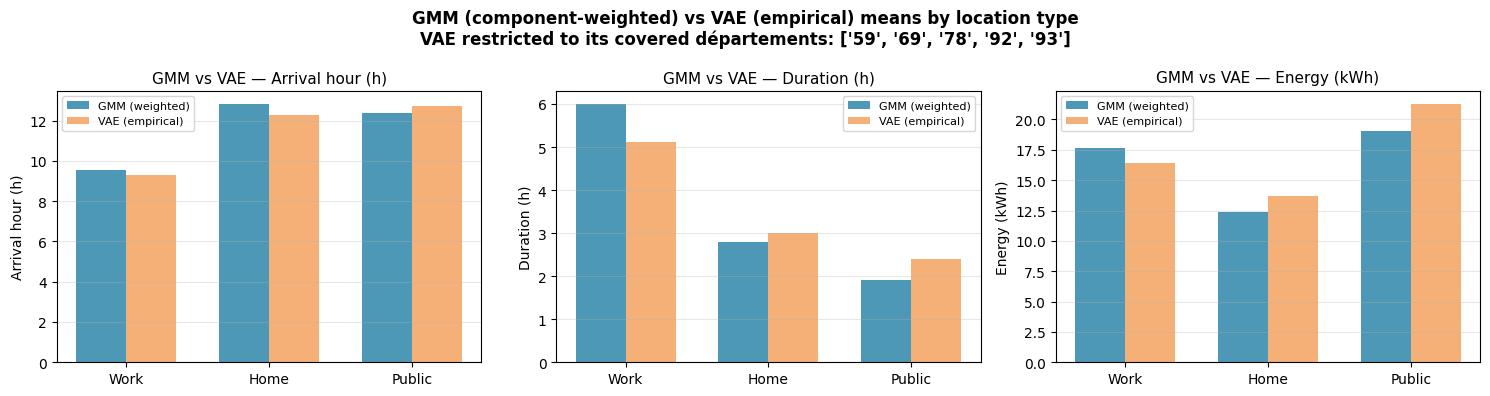

In [12]:
# ── Empirical means from the VAE (sample → average), one location type at a time ─
def vae_empirical_means(loc_filter=None, n_samples=3000, seed=0):
    rows = []
    for ctx in vae.list_contexts():
        ctx_d = dict(zip(vae.stratify_by, ctx))
        if loc_filter and ctx_d.get("location_type") != loc_filter:
            continue
        samp = vae.sample(n_samples // 10, context=ctx_d, seed=seed)  # small per-context draw
        rows.append({
            "location_type": ctx_d["location_type"],
            "arrival_hour": samp["arrival_hour"].mean(),
            "duration_h": samp["duration"].mean(),
            "energy_kwh": samp["energy"].mean(),
        })
    return pd.DataFrame(rows)

vae_means = vae_empirical_means()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [("arrival_hour", "Arrival hour (h)"),
           ("duration_h",   "Duration (h)"),
           ("energy_kwh",   "Energy (kWh)")]

for ax, (metric, label) in zip(axes, metrics):
    gmm_vals, vae_vals, labels = [], [], []
    for loc in ["work", "home", "public"]:
        sub_gmm = all_means[all_means["location_type"] == loc]
        sub_vae = vae_means[vae_means["location_type"] == loc]
        if sub_gmm.empty or sub_vae.empty:
            continue
        gmm_vals.append(np.average(sub_gmm[metric], weights=sub_gmm["weight"]))
        vae_vals.append(sub_vae[metric].mean())
        labels.append(loc.capitalize())
    x = np.arange(len(labels)); w = 0.35
    ax.bar(x - w/2, gmm_vals, width=w, label="GMM (weighted)", color="#2E86AB", alpha=0.85)
    ax.bar(x + w/2, vae_vals, width=w, label="VAE (empirical)", color="#F4A261", alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylabel(label); ax.set_title(f"GMM vs VAE — {label}", fontsize=11)
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

fig.suptitle("GMM (component-weighted) vs VAE (empirical) means by location type\n"
             f"VAE restricted to its covered départements: {sorted(depts_vae)}",
             fontsize=12, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/01_gmm_vs_vae_location_means.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Descriptive statistics per stratum

Summary statistics derived from GMM component means (weighted by mixture weights).  
Each stratum is a `(location_type, department, day_of_week, season)` context.

In [13]:
# ── Build full summary: one row per context ──────────────────────────────────
summary_rows = []
for ctx, sk in gmm.models_.items():
    ctx_d = dict(zip(gmm.stratify_by, ctx))
    n_samp = gmm.context_counts_.get(ctx, 0)
    # Weighted means (back-transformed)
    w_arrival  = float(np.average(sk.means_[:, 0], weights=sk.weights_))
    w_duration = float(np.average(np.expm1(sk.means_[:, 1]), weights=sk.weights_))
    w_energy   = float(np.average(np.expm1(sk.means_[:, 2]), weights=sk.weights_))
    summary_rows.append({
        **ctx_d,
        "n_components": sk.n_components,
        "n_samples": n_samp,
        "mean_arrival_h": round(w_arrival, 2),
        "mean_duration_h": round(w_duration, 2),
        "mean_energy_kwh": round(w_energy, 2),
    })

ctx_df = pd.DataFrame(summary_rows)

# ── Per-stratum summary: aggregate by location_type × season ────────────────
agg = (
    ctx_df
    .groupby(["location_type", "season"])
    .agg(
        n_contexts=("n_components", "count"),
        total_samples=("n_samples", "sum"),
        mean_arrival_h=("mean_arrival_h", "mean"),
        mean_duration_h=("mean_duration_h", "mean"),
        mean_energy_kwh=("mean_energy_kwh", "mean"),
    )
    .round(2)
    .reset_index()
)
season_order = ["winter", "spring", "summer", "autumn"]
agg["season"] = pd.Categorical(agg["season"], categories=season_order, ordered=True)
agg = agg.sort_values(["location_type", "season"])

print("── Summary statistics per stratum (location_type × season) ─────────────────")
print(agg.to_string(index=False))

── Summary statistics per stratum (location_type × season) ─────────────────
location_type season  n_contexts  total_samples  mean_arrival_h  mean_duration_h  mean_energy_kwh
        heavy winter         292          20998           12.77             9.47            85.09
        heavy spring         293          20944           12.62            11.27            80.37
        heavy summer         297          21272           12.15             9.86            87.16
        heavy autumn         305          26451           12.11            10.20            88.85
         home winter         389         191136           12.62             2.83            12.06
         home spring         387         189044           12.18             2.77            12.32
         home summer         381         169062           12.20             2.74            12.52
         home autumn         388         193373           14.34             2.87            12.59
       public winter         680        1

### 4.1 Same descriptive-stats aggregation for the VAE (via empirical sampling)

`ctx_df`/`agg` above were built by reading `sk.means_`/`sk.weights_` directly off each GMM context —
not possible for the VAE. Building the equivalent table means sampling each VAE context instead. Kept to
one département (the one resolved above as `VAE_DEMO_DEPT`) and the three main location types to stay fast.


In [14]:
# ── VAE per-stratum summary via sampling (dept 92 only, for a clean side-by-side) ──
vae_summary_rows = []
for ctx in vae.list_contexts():
    ctx_d = dict(zip(vae.stratify_by, ctx))
    if ctx_d.get("department") != VAE_DEMO_DEPT or ctx_d["location_type"] not in ("work", "home", "public"):
        continue
    samp = vae.sample(300, context=ctx_d, seed=1)
    vae_summary_rows.append({
        **ctx_d,
        "n_components": 1,
        "n_samples": vae.context_counts_.get(ctx, 0),
        "mean_arrival_h": round(samp["arrival_hour"].mean(), 2),
        "mean_duration_h": round(samp["duration"].mean(), 2),
        "mean_energy_kwh": round(samp["energy"].mean(), 2),
    })
vae_ctx_df = pd.DataFrame(vae_summary_rows)

gmm_dept92 = ctx_df[(ctx_df["department"] == GMM_DEMO_DEPT) & (ctx_df["location_type"].isin(["work", "home", "public"]))]
compare = (
    gmm_dept92.groupby("location_type")["mean_energy_kwh"].mean().rename("GMM (weighted means)")
    .to_frame()
    .join(vae_ctx_df.groupby("location_type")["mean_energy_kwh"].mean().rename("VAE (empirical, sampled)"))
)
print(f"── Mean energy (kWh) — GMM dept {GMM_DEMO_DEPT!r} vs VAE dept {VAE_DEMO_DEPT!r} ──────────")
print(compare.round(2).to_string())

── Mean energy (kWh) — GMM dept '59' vs VAE dept '59' ──────────
               GMM (weighted means)  VAE (empirical, sampled)
location_type                                                
home                          13.78                     21.08
public                        20.03                     23.77
work                          16.98                     19.44


## 5. Session distributions by location type

Simulate 2 000 sessions per location type and plot marginal distributions.

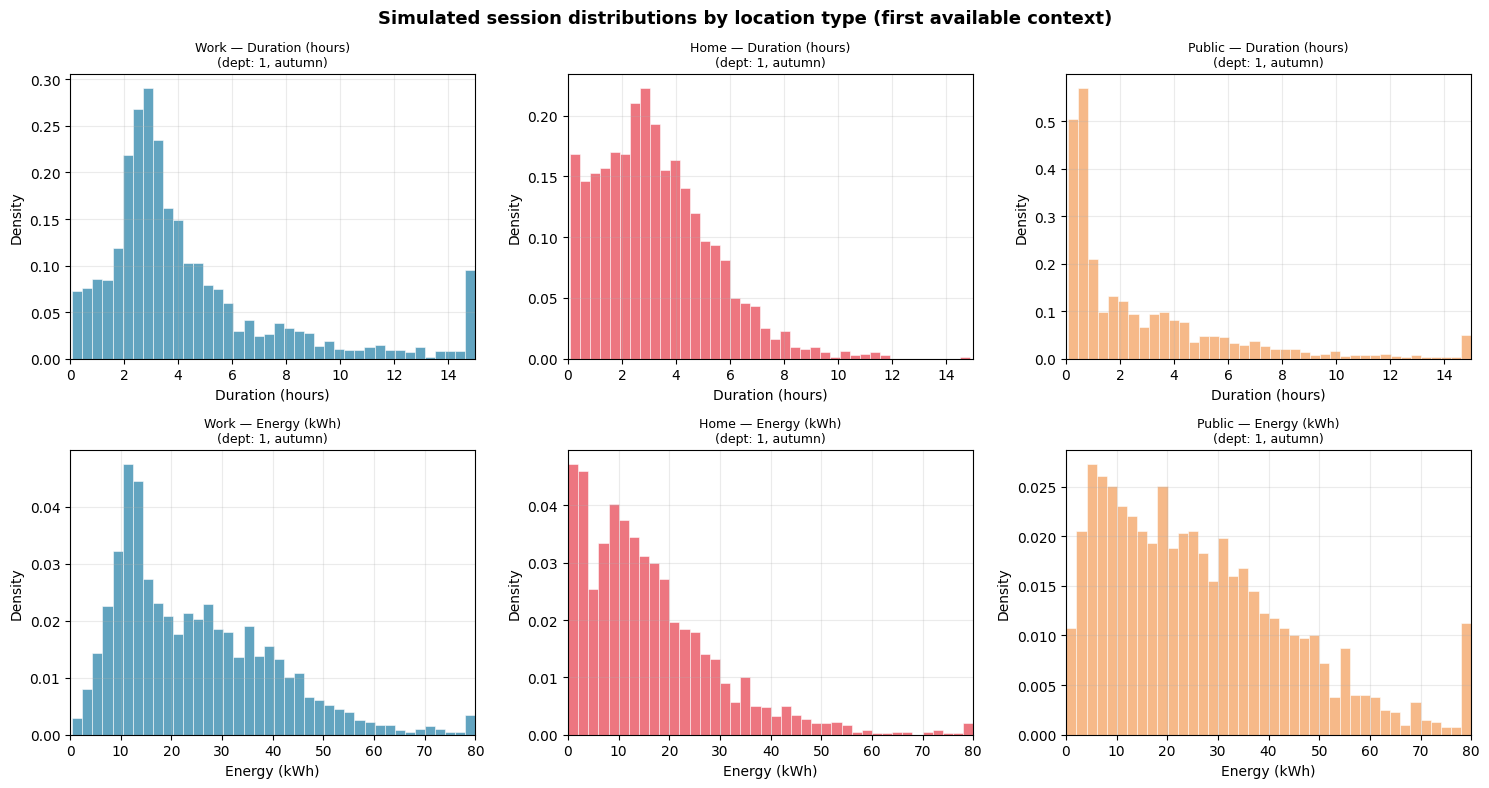

In [15]:
# ── Simulated marginal distributions — duration & energy by location type ───
def first_ctx(loc_type):
    """Return context dict for the first available context of this location type."""
    ctx_key = next((c for c in gmm.list_contexts() if c[0] == loc_type), None)
    return dict(zip(gmm.stratify_by, ctx_key)) if ctx_key else None

loc_configs = [
    ("Work",   "work",   first_ctx("work"),   COLORS["work"]),
    ("Home",   "home",   first_ctx("home"),   COLORS["home"]),
    ("Public", "public", first_ctx("public"), COLORS["public"]),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, (label, loc, ctx, color) in enumerate(loc_configs):
    samp = gmm.sample(2000, context=ctx, seed=42)
    for row, (feat, xlabel, xlim) in enumerate([
        ("duration", "Duration (hours)", (0, 15)),
        ("energy",   "Energy (kWh)",     (0, 80)),
    ]):
        ax = axes[row, col]
        ax.hist(samp[feat].clip(0, xlim[1]), bins=40, density=True,
                color=color, alpha=0.75, edgecolor="white", linewidth=0.5)
        ax.set_xlabel(xlabel); ax.set_ylabel("Density")
        ax.set_xlim(0, xlim[1])
        ax.set_title(f"{label} — {xlabel}\n(dept: {ctx['department']}, {ctx['season']})", fontsize=9)
        ax.grid(True, alpha=0.25)

fig.suptitle("Simulated session distributions by location type (first available context)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/01_marginals_by_location.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.1 `.plot_marginals()` — GMM vs VAE, same method call

`plot_marginals()` is defined on the shared `EVSessionModel` wrapper and only calls `.sample()` internally,
so it works identically regardless of `model_type`. Below, GMM and VAE marginals are shown stacked for
the same three location types (départements resolved above as `GMM_DEMO_DEPT`/`VAE_DEMO_DEPT`) so the
shapes can be compared directly.


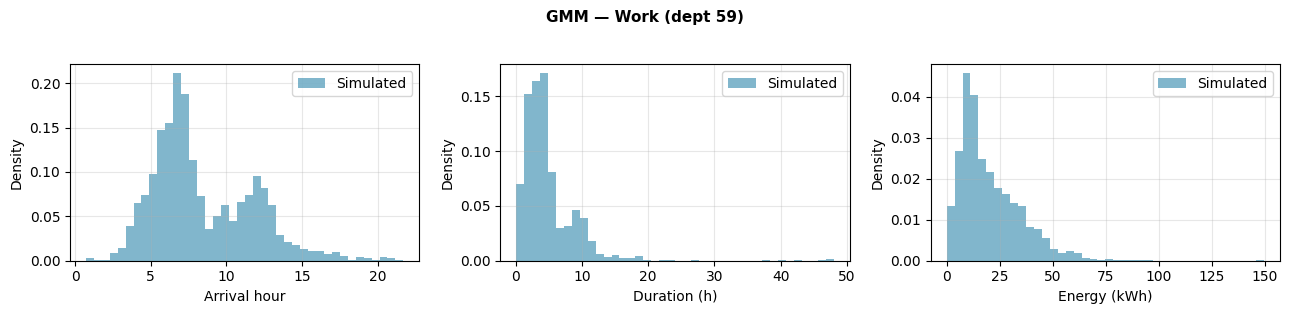

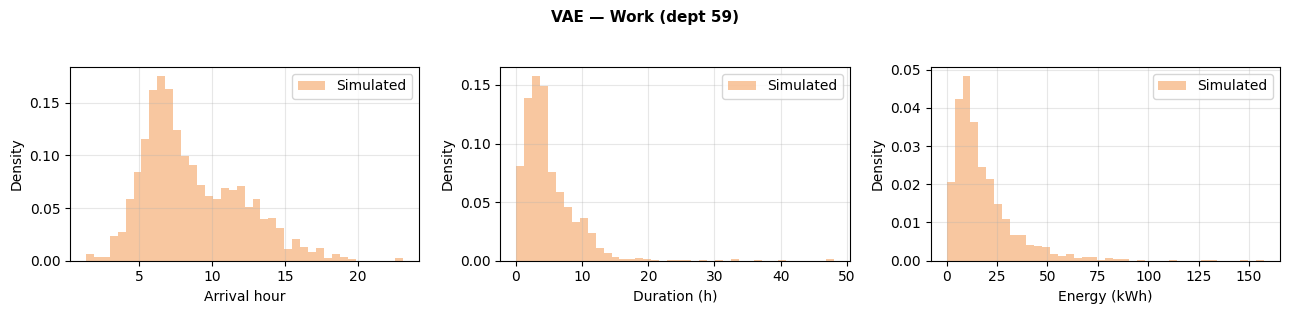

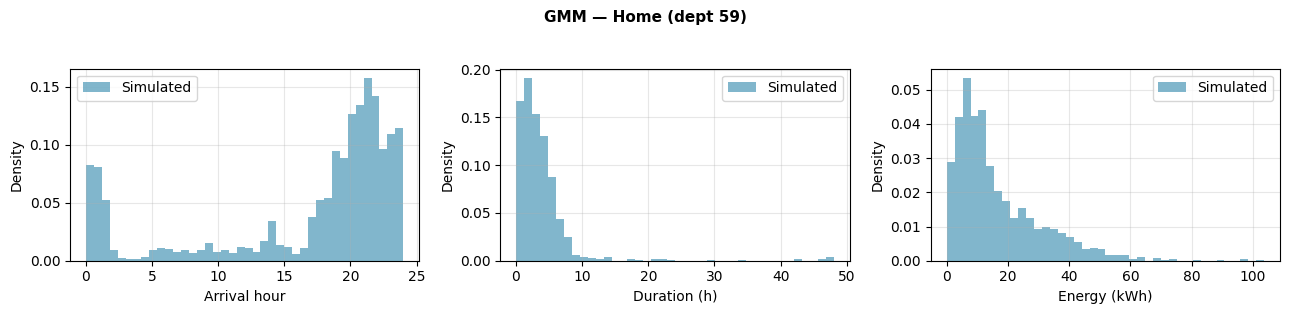

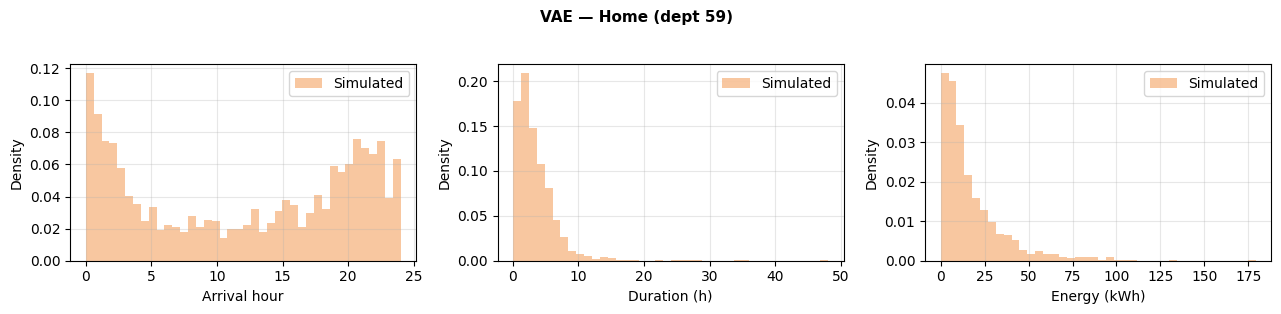

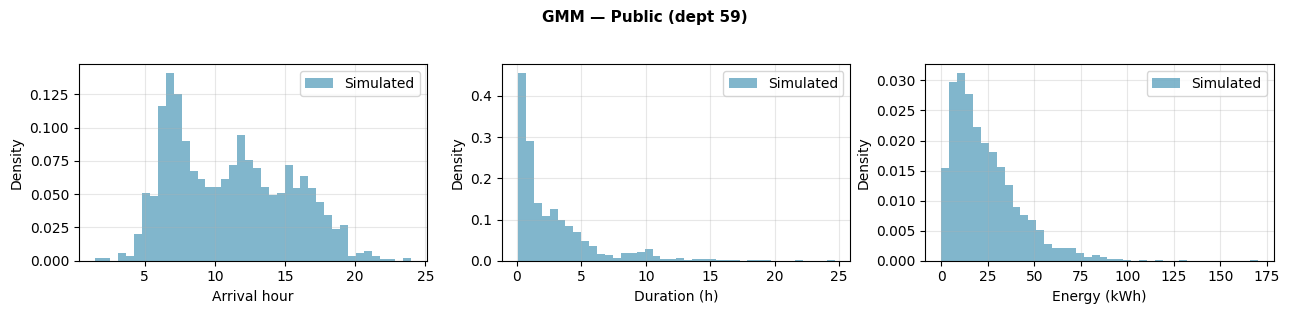

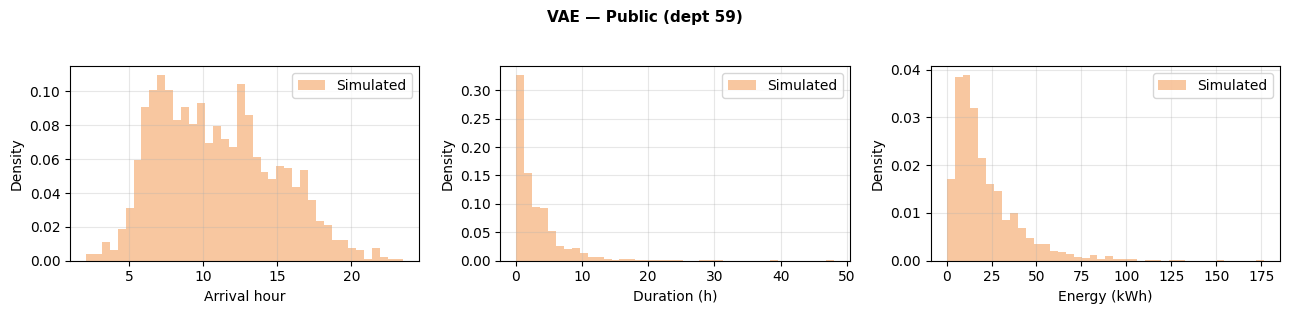

In [16]:
# ── plot_marginals(): GMM vs VAE, same contexts (dept 92) ───────────────────────
for loc in ["work", "home", "public"]:
    ctx_gmm_d = first_ctx(loc)
    ctx_gmm_d = {**ctx_gmm_d, "department": GMM_DEMO_DEPT} if ctx_gmm_d else None
    ctx_vae_d = next((d for d in (dict(zip(vae.stratify_by, c)) for c in vae.list_contexts())
                      if d.get("location_type") == loc and d.get("department") == VAE_DEMO_DEPT), None)
    if ctx_gmm_d is None or ctx_vae_d is None:
        continue
    fig_gmm = gmm.plot_marginals(context=ctx_gmm_d, n_samples=1500, figsize=(13, 3))
    fig_gmm.suptitle(f"GMM — {loc.capitalize()} (dept {GMM_DEMO_DEPT})", fontsize=11, fontweight="bold", y=1.03)
    fig_gmm.tight_layout()
    plt.savefig(f"outputs/01_marginals_gmm_{loc}.png", dpi=150, bbox_inches="tight")
    plt.show()

    fig_vae = vae.plot_marginals(context=ctx_vae_d, n_samples=1500, figsize=(13, 3))
    fig_vae.suptitle(f"VAE — {loc.capitalize()} (dept {VAE_DEMO_DEPT})", fontsize=11, fontweight="bold", y=1.03)
    fig_vae.tight_layout()
    plt.savefig(f"outputs/01_marginals_vae_{loc}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 6. Seasonal patterns — arrival hour by season

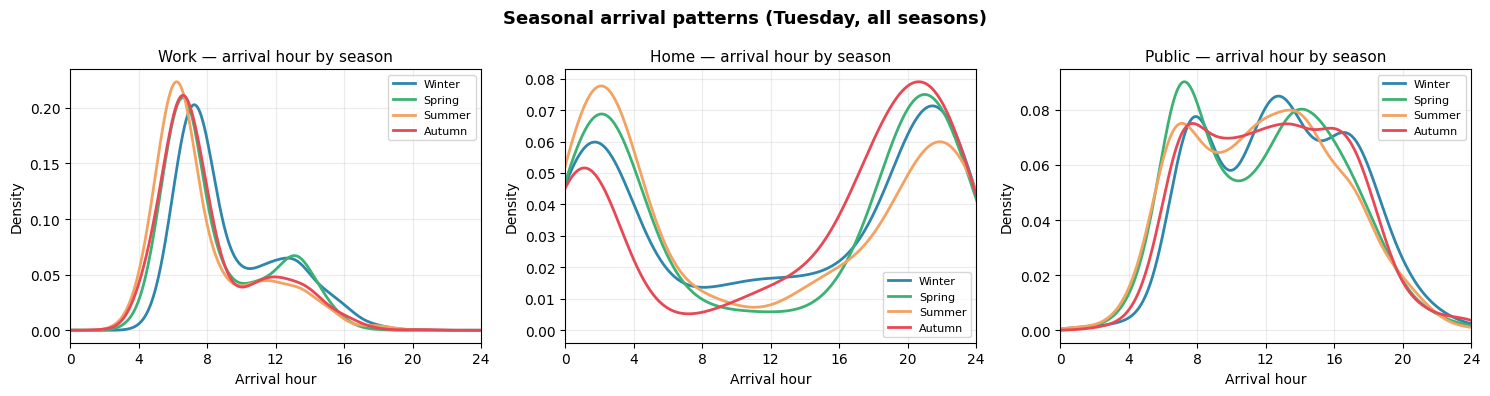

In [17]:
# ── Arrival-hour KDE by season × location type ──────────────────────────────
SEASONS = ["winter", "spring", "summer", "autumn"]
SEASON_COLORS = {
    "winter": "#2E86AB", "spring": "#3BB273",
    "summer": "#F4A261", "autumn": "#E84855",
}

def find_ctx(loc_type, season, dow_pref=1):
    """Return a context dict for a given (loc_type, season)."""
    # Prefer a weekday context (dow=1) for a fair seasonal comparison
    for ctx in gmm.list_contexts():
        ctx_d = dict(zip(gmm.stratify_by, ctx))
        if ctx_d.get("location_type") == loc_type and ctx_d.get("season") == season:
            if ctx_d.get("day_of_week") == dow_pref:
                return ctx_d
    # Fallback: any context with this loc_type + season
    for ctx in gmm.list_contexts():
        ctx_d = dict(zip(gmm.stratify_by, ctx))
        if ctx_d.get("location_type") == loc_type and ctx_d.get("season") == season:
            return ctx_d
    return None

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, loc in zip(axes, ["work", "home", "public"]):
    for season in SEASONS:
        ctx = find_ctx(loc, season)
        if ctx is None:
            continue
        samp = gmm.sample(1500, context=ctx, seed=0)
        samp["arrival_hour"].plot.kde(
            ax=ax, label=season.capitalize(),
            color=SEASON_COLORS[season], linewidth=2,
        )
    ax.set_xlim(0, 24)
    ax.set_xticks(range(0, 25, 4))
    ax.set_xlabel("Arrival hour"); ax.set_ylabel("Density")
    ax.set_title(f"{loc.capitalize()} — arrival hour by season", fontsize=11)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.25)

fig.suptitle("Seasonal arrival patterns (Tuesday, all seasons)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/01_arrival_by_season.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.1 Same seasonal KDE for the VAE (sampling only — département resolved above)


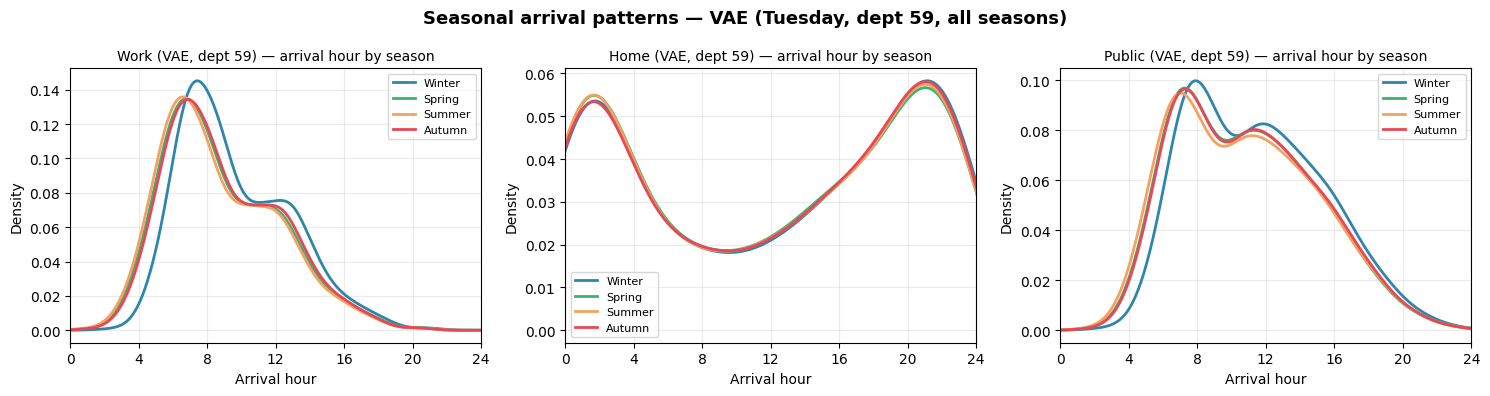

In [18]:
# ── Arrival-hour KDE by season × location type — VAE version ────────────────────
def find_ctx_vae(loc_type, season, dept=VAE_DEMO_DEPT, dow_pref=1):
    for ctx in vae.list_contexts():
        ctx_d = dict(zip(vae.stratify_by, ctx))
        if ctx_d.get("location_type") == loc_type and ctx_d.get("season") == season and ctx_d.get("department") == dept:
            if ctx_d.get("day_of_week") == dow_pref:
                return ctx_d
    for ctx in vae.list_contexts():
        ctx_d = dict(zip(vae.stratify_by, ctx))
        if ctx_d.get("location_type") == loc_type and ctx_d.get("season") == season and ctx_d.get("department") == dept:
            return ctx_d
    return None

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, loc in zip(axes, ["work", "home", "public"]):
    for season in SEASONS:
        ctx = find_ctx_vae(loc, season)
        if ctx is None:
            continue
        samp = vae.sample(1500, context=ctx, seed=0)
        samp["arrival_hour"].plot.kde(
            ax=ax, label=season.capitalize(),
            color=SEASON_COLORS[season], linewidth=2,
        )
    ax.set_xlim(0, 24)
    ax.set_xticks(range(0, 25, 4))
    ax.set_xlabel("Arrival hour"); ax.set_ylabel("Density")
    ax.set_title(f"{loc.capitalize()} (VAE, dept {VAE_DEMO_DEPT}) — arrival hour by season", fontsize=10)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.25)

fig.suptitle(f"Seasonal arrival patterns — VAE (Tuesday, dept {VAE_DEMO_DEPT}, all seasons)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/01_arrival_by_season_vae.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Day-of-week patterns

Weighted average arrival hour and energy by day-of-week, computed from component means.

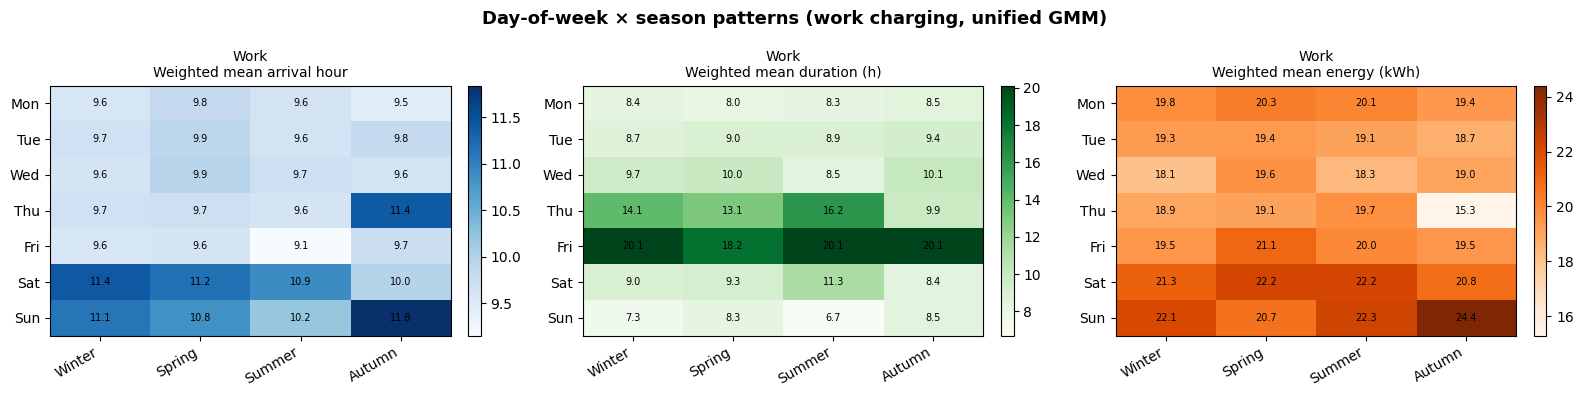

In [19]:
# ── Day-of-week × season heatmap (Work contexts) ────────────────────────────
DOW_LABELS   = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
SEASON_ORDER = ["winter", "spring", "summer", "autumn"]

def dow_season_matrix(gmm_obj, metric="arrival_hour", loc_filter=None):
    """Build (7 × 4) matrix of weighted component means."""
    mat = np.full((7, 4), np.nan)
    for ctx, sk in gmm_obj.models_.items():
        ctx_d = dict(zip(gmm_obj.stratify_by, ctx))
        if loc_filter and ctx_d.get("location_type") != loc_filter:
            continue
        dow = ctx_d.get("day_of_week")
        sea = ctx_d.get("season")
        if dow is None or sea not in SEASON_ORDER:
            continue
        si = SEASON_ORDER.index(sea)
        if metric == "arrival_hour":
            vals = sk.means_[:, 0]
        elif metric == "energy_kwh":
            vals = np.expm1(sk.means_[:, 2])
        else:
            vals = np.expm1(sk.means_[:, 1])
        # Accumulate (average across multiple departments per cell)
        cell_val = np.average(vals, weights=sk.weights_)
        if np.isnan(mat[dow, si]):
            mat[dow, si] = cell_val
        else:
            mat[dow, si] = (mat[dow, si] + cell_val) / 2
    return mat

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
heatmap_metrics = [
    ("arrival_hour", "Weighted mean arrival hour", "Blues"),
    ("duration_h",   "Weighted mean duration (h)", "Greens"),
    ("energy_kwh",   "Weighted mean energy (kWh)", "Oranges"),
]
for ax, (metric, title, cmap) in zip(axes, heatmap_metrics):
    mat = dow_season_matrix(gmm, metric, loc_filter="work")
    im = ax.imshow(mat, aspect="auto", cmap=cmap, interpolation="nearest")
    ax.set_xticks(range(4))
    ax.set_xticklabels([s.capitalize() for s in SEASON_ORDER], rotation=30, ha="right")
    ax.set_yticks(range(7)); ax.set_yticklabels(DOW_LABELS)
    ax.set_title(f"Work\n{title}", fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for i in range(7):
        for j in range(4):
            if not np.isnan(mat[i, j]):
                ax.text(j, i, f"{mat[i, j]:.1f}", ha="center", va="center",
                        fontsize=7, color="black")

fig.suptitle("Day-of-week × season patterns (work charging, unified GMM)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/01_dow_season_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

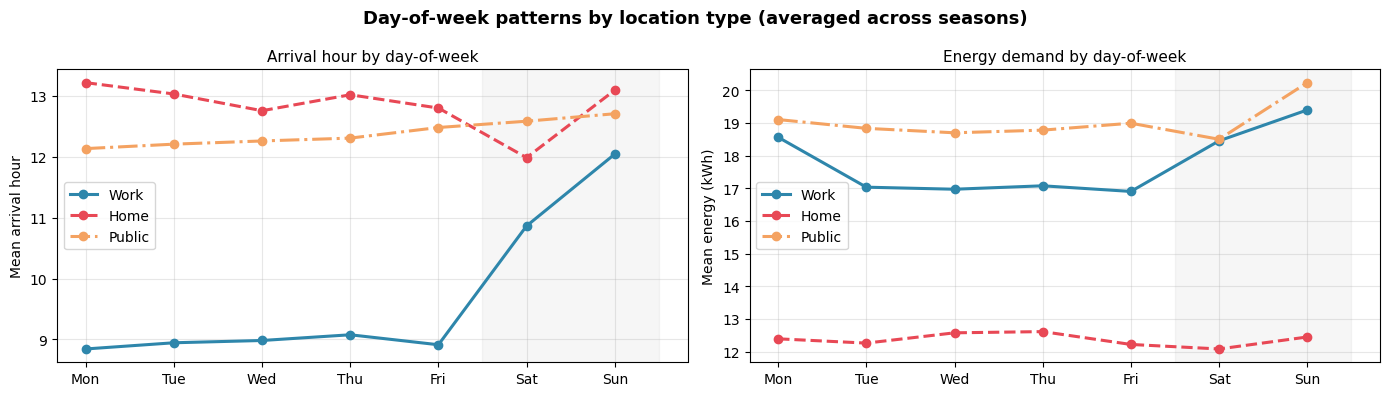

In [20]:
# ── Day-of-week line plots: mean arrival hour & energy (all 3 location types) ─
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
loc_styles = [
    ("work",   "#2E86AB", "-"),
    ("home",   "#E84855", "--"),
    ("public", "#F4A261", "-."),
]

for metric_idx, (ax, ylabel, title) in enumerate(zip(axes,
    ["Mean arrival hour", "Mean energy (kWh)"],
    ["Arrival hour by day-of-week", "Energy demand by day-of-week"]
)):
    for loc, color, ls in loc_styles:
        dow_vals = []
        for d in range(7):
            vals_all, weights_all = [], []
            for ctx, sk in gmm.models_.items():
                ctx_d = dict(zip(gmm.stratify_by, ctx))
                if ctx_d.get("location_type") != loc:
                    continue
                if ctx_d.get("day_of_week") != d:
                    continue
                if metric_idx == 0:
                    vals_all.extend(sk.means_[:, 0].tolist())
                else:
                    vals_all.extend(np.expm1(sk.means_[:, 2]).tolist())
                weights_all.extend(sk.weights_.tolist())
            dow_vals.append(np.average(vals_all, weights=weights_all) if vals_all else np.nan)
        ax.plot(range(7), dow_vals, color=color, linestyle=ls, linewidth=2.2,
                marker="o", markersize=6, label=loc.capitalize())
    ax.set_xticks(range(7)); ax.set_xticklabels(DOW_LABELS)
    ax.set_ylabel(ylabel); ax.set_title(title, fontsize=11)
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.axvspan(4.5, 6.5, alpha=0.07, color="gray")

fig.suptitle("Day-of-week patterns by location type (averaged across seasons)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/01_dow_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.1 Day-of-week patterns from the VAE (empirical, via sampling)

The heatmap above reads `sk.means_`/`sk.weights_` directly — GMM-specific. For the VAE, the same
day-of-week story is recovered empirically (sample each `(location_type, day_of_week)` context, dept 92,
average across seasons) and plotted the same way as the GMM line chart for a direct visual comparison.

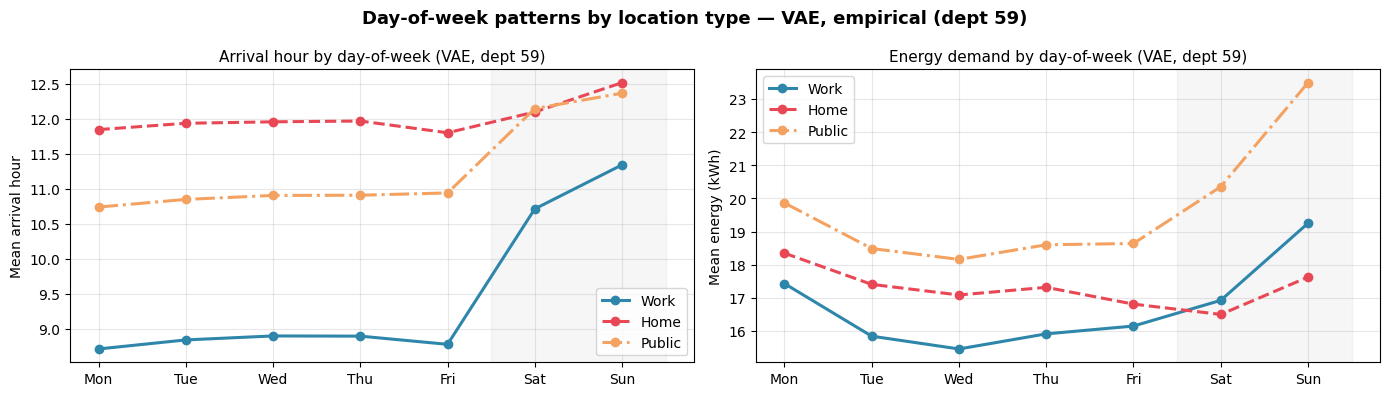

In [21]:
# ── Day-of-week line plots from the VAE (empirical, dept 92) ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for metric_idx, (ax, ylabel, title) in enumerate(zip(axes,
    ["Mean arrival hour", "Mean energy (kWh)"],
    [f"Arrival hour by day-of-week (VAE, dept {VAE_DEMO_DEPT})", f"Energy demand by day-of-week (VAE, dept {VAE_DEMO_DEPT})"]
)):
    for loc, color, ls in loc_styles:
        dow_vals = []
        for d in range(7):
            vals = []
            for ctx in vae.list_contexts():
                ctx_d = dict(zip(vae.stratify_by, ctx))
                if ctx_d.get("location_type") != loc or ctx_d.get("department") != VAE_DEMO_DEPT or ctx_d.get("day_of_week") != d:
                    continue
                samp = vae.sample(200, context=ctx_d, seed=2)
                vals.extend((samp["arrival_hour"] if metric_idx == 0 else samp["energy"]).tolist())
            dow_vals.append(np.mean(vals) if vals else np.nan)
        ax.plot(range(7), dow_vals, color=color, linestyle=ls, linewidth=2.2,
                marker="o", markersize=6, label=loc.capitalize())
    ax.set_xticks(range(7)); ax.set_xticklabels(DOW_LABELS)
    ax.set_ylabel(ylabel); ax.set_title(title, fontsize=11)
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.axvspan(4.5, 6.5, alpha=0.07, color="gray")

fig.suptitle(f"Day-of-week patterns by location type — VAE, empirical (dept {VAE_DEMO_DEPT})",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/01_dow_patterns_vae.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Département coverage

Training sample count by département.


In [22]:
# ── Département coverage table ────────────────────────────────────────────────
def dept_coverage(gmm_obj):
    """Aggregate context stats by department."""
    rows = []
    for ctx, sk in gmm_obj.models_.items():
        ctx_d = dict(zip(gmm_obj.stratify_by, ctx))
        rows.append({
            "department": ctx_d.get("department", "all"),
            "n_components": sk.n_components,
            "n_samples": gmm_obj.context_counts_.get(ctx, 0),
        })
    df_cov = pd.DataFrame(rows)
    return (
        df_cov.groupby("department")
        .agg(n_contexts=("n_components", "count"),
             mean_k=("n_components", "mean"),
             total_samples=("n_samples", "sum"))
        .reset_index()
        .sort_values("total_samples", ascending=False)
    )

cov_global = dept_coverage(gmm)
print(f"Departments covered: {len(cov_global)}")
print(cov_global.to_string(index=False))

Departments covered: 100
department  n_contexts    mean_k  total_samples
        92         112  9.196429         384837
        78         108 10.101852         299806
        69         108 11.416667         293985
        94         109  9.238532         258878
        31         110  8.290909         244771
        59         104  9.278846         241174
        13         108 10.490741         229087
        33         108  9.453704         209163
        91          91  9.384615         207403
        93         110  9.181818         203119
        75         108  9.592593         202102
         6         110 10.000000         193318
        95         112  9.133929         191033
        44         104  9.067308         174059
        38         112  7.348214         170690
        67         110  9.500000         168548
        77         112  8.660714         166269
        57          89  9.662921         153576
        62         109  7.339450         151533
        76     

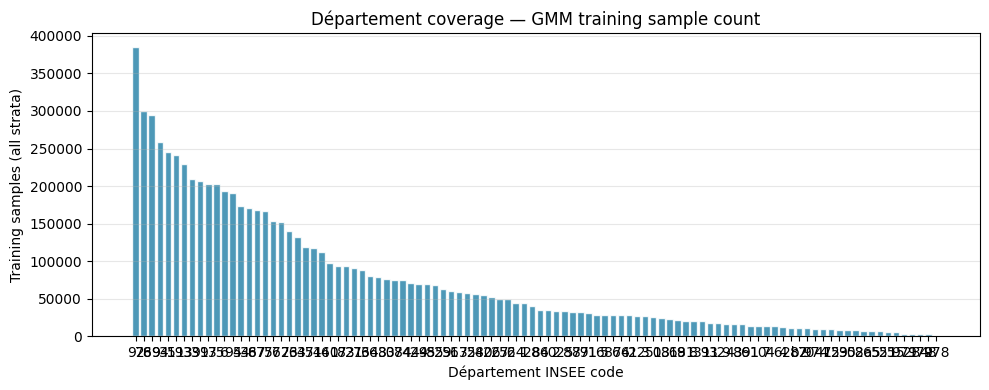

In [23]:
# ── Bar chart: departments by training sample count ────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(
    cov_global["department"].astype(str),
    cov_global["total_samples"],
    color="#2E86AB", alpha=0.85, edgecolor="white",
)
ax.set_xlabel("Département INSEE code")
ax.set_ylabel("Training samples (all strata)")
ax.set_title("Département coverage — GMM training sample count", fontsize=12)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.savefig("outputs/01_dept_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.1 Département coverage — VAE bundle (sample)

`dept_coverage()` only reads `sk.n_components` and `gmm_obj.context_counts_` — both present on the VAE
wrapper too, so the exact same function call works unmodified. The VAE "sample" bundle covers however
many départements it was fit/fell back on in this environment (printed below) — fewer than the full
`"french"` GMM bundle, which covers all 100.


Departments covered (VAE sample bundle): 5
department  n_contexts  mean_k  total_samples
        92         112     1.0         208868
        69         108     1.0         134181
        59          87     1.0         128654
        78         104     1.0         114006
        93         105     1.0         105303


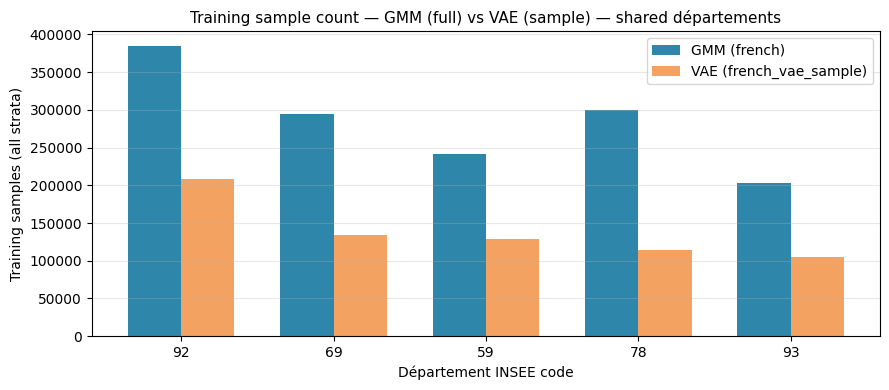

In [24]:
if vae_has_dept:
    cov_vae = dept_coverage(vae)
    print(f"Departments covered (VAE sample bundle): {len(cov_vae)}")
    print(cov_vae.to_string(index=False))

    # Side-by-side bar chart for the départements the VAE bundle covers
    shared_depts = cov_vae["department"].tolist()
    cov_gmm_shared = cov_global[cov_global["department"].isin(shared_depts)].set_index("department")
    cov_vae_shared = cov_vae.set_index("department")

    fig, ax = plt.subplots(figsize=(9, 4))
    x = np.arange(len(shared_depts)); w = 0.35
    ax.bar(x - w/2, cov_gmm_shared.loc[shared_depts, "total_samples"], width=w, label="GMM (french)", color="#2E86AB")
    ax.bar(x + w/2, cov_vae_shared.loc[shared_depts, "total_samples"], width=w, label="VAE (french_vae_sample)", color="#F4A261")
    ax.set_xticks(x); ax.set_xticklabels(shared_depts)
    ax.set_xlabel("Département INSEE code"); ax.set_ylabel("Training samples (all strata)")
    ax.set_title("Training sample count — GMM (full) vs VAE (sample) — shared départements", fontsize=11)
    ax.legend(); ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.savefig("outputs/01_dept_coverage_gmm_vs_vae.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(
        "This VAE bundle does not stratify by département at all "
        f"(stratify_by={vae.stratify_by!r}), so there is no per-département coverage "
        "to compare against the GMM bundle here — skipping the bar chart. "
        "See the alignment note earlier in this notebook."
    )

## 9. BIC component count summary

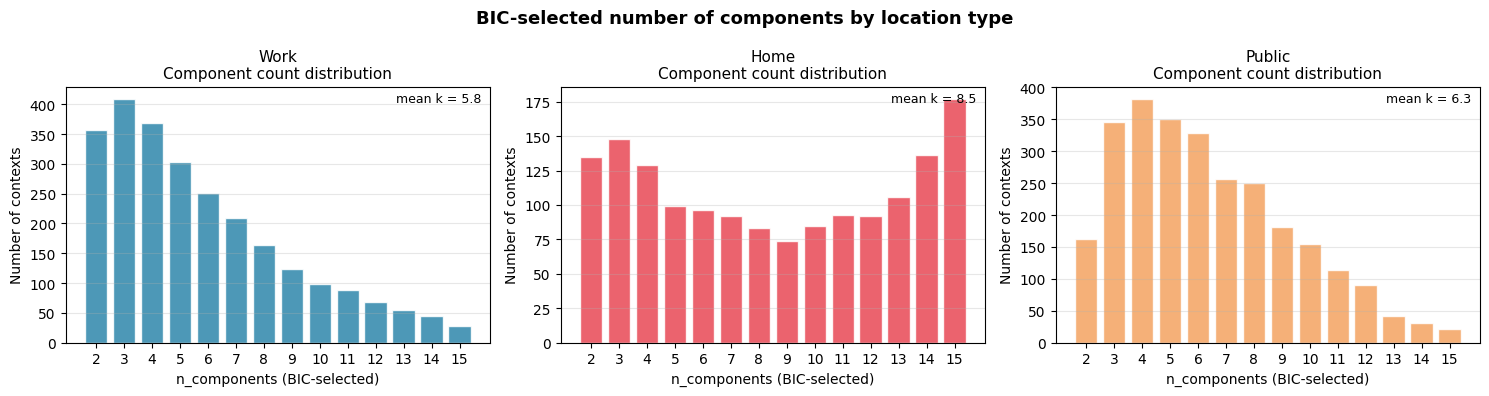

In [25]:
# ── BIC-selected number of components per context ────────────────────────────
bic_all = gmm.bic_summary()
# Add location_type column from context tuple
bic_all["location_type"] = bic_all["context"].apply(lambda c: c[0])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (loc, color) in zip(axes, [
    ("work",   COLORS["work"]),
    ("home",   COLORS["home"]),
    ("public", COLORS["public"]),
]):
    bdf = bic_all[bic_all["location_type"] == loc]
    vc  = bdf["n_components"].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color=color, alpha=0.85, edgecolor="white")
    mean_k = bdf["n_components"].mean()
    ax.set_xlabel("n_components (BIC-selected)")
    ax.set_ylabel("Number of contexts")
    ax.set_title(f"{loc.capitalize()}\nComponent count distribution", fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    ax.text(0.98, 0.98, f"mean k = {mean_k:.1f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=9)

fig.suptitle("BIC-selected number of components by location type", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.savefig("outputs/01_bic_components.png", dpi=150, bbox_inches="tight")
plt.show()

### 9.1 `.bic_summary()` on the VAE — same method, trivially `n_components == 1`

`bic_summary()` only reads `.n_components` per context, so it runs unmodified on the VAE. The result is
uninteresting by construction (every row is `1`) — which is itself the point: BIC-based component-count
selection is a GMM-specific model-selection step that doesn't apply to a VAE's continuous latent space.

In [26]:
bic_vae = vae.bic_summary()
print(f"VAE bic_summary(): n_components value counts (expect a single value, 1):")
print(bic_vae["n_components"].value_counts().to_string())
print(f"\nTotal VAE contexts: {len(bic_vae)}, all with n_components={bic_vae['n_components'].unique().tolist()}")

VAE bic_summary(): n_components value counts (expect a single value, 1):
n_components
1    516

Total VAE contexts: 516, all with n_components=[1]


## Summary

| Item | GMM (`french`) | VAE (`french_vae_sample`) |
|---|---|---|
| Registry bundle | unified GMM object | unified VAE object, `model_type="vae"` |
| Stratification | `location_type × department × day_of_week × season` | same |
| Location types | `work`, `home`, `public`, `heavy` | same (subset of départements) |
| Départements covered | all 100 départements | a small subset (see §8.1 above), `is_sample_=True` |
| Retrieval API | `gears.get_session_model("french")` **or** `NativeSessionModelRegistry().load("french")` | `gears.get_session_model("french_vae_sample")` **or** `NativeSessionModelRegistry().load("french_vae_sample")` |
| Underlying object | `sklearn.mixture.GaussianMixture` | `gears.models.vae.VAEContextSlice` |
| `n_components` | typically 3–7 (BIC-selected) | always `1` (continuous decoder, not a discrete mixture) |
| `.sample()`, `.score()`, `.plot_marginals()`, `.plot_components()`, `.bic_summary()`, `.get_sklearn_component()` | ✓ | ✓ — identical calls, same return shapes |
| Introspecting `.means_` / `.covariances_` directly | ✓ | ✗ — not exposed; use `.sample()` + empirical stats instead |

**Key observations:**
- Work charging peaks sharply at 08–09h on weekdays, diffuse on weekends — consistent between GMM and VAE
- Home charging peaks in the evening (18–21h), stable across seasons — consistent between GMM and VAE
- Public charging shows a bimodal pattern (lunch + evening)
- The VAE reproduces the same marginal shapes as the GMM (Section 5.1) despite having no discrete mixture
  structure to introspect — the two are behaviourally interchangeable via the shared `.sample()`/`.score()`
  API, even though the GMM alone lets you read off interpretable component parameters directly.
- The VAE "sample" bundle trades national département coverage for a (currently) smaller footprint —
  useful for quick iteration, not a full replacement for the `"french"` GMM bundle yet.